# Avance 1: Comprensión EDA

## 1. Carga de liberías y Datos
En esta sección preparamos el entorno y cargamos los datos procesados en la etapa anterior.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from cargar_datos import cargarDatos

df = cargarDatos()
df_original = cargarDatos()
df = df_original.copy()

       tipo_credito      fecha_prestamo  capital_prestado  plazo_meses  \
0                 7 2024-12-21 11:31:35      3,692,160.00           10   
1                 4 2025-04-22 09:47:35        840,000.00            6   
2                 9 2026-01-08 12:22:40      5,974,028.40           10   
3                 4 2025-08-04 12:04:10      1,671,240.00            6   
4                 9 2025-04-26 11:24:26      2,781,636.00           11   
...             ...                 ...               ...          ...   
10758             9 2025-01-19 16:18:28      2,414,886.00           10   
10759             4 2025-01-10 16:40:21      2,916,000.00           24   
10760             4 2025-06-19 14:28:47      4,249,200.00           36   
10761             9 2025-03-02 11:53:41      1,283,307.60           10   
10762             4 2024-12-08 12:46:03      3,915,000.00           12   

       edad_cliente   tipo_laboral  salario_cliente  total_otros_prestamos  \
0                42  Independient

In [28]:
df['tendencia_ingresos'].unique()


array(['Estable', 'Creciente', nan, 'Decreciente', 8315, 0, 158042, 3978,
       9147, 168750, -28589, 1000000, -566272, 24702, 31837, 122727,
       417087, 9090, 173031, -70715, -435177, -702927, -4105, 54683,
       22832, 209090, 5697, 10808, -288, -164315, 2029000, 17181, 15245,
       82657, 52862, 1817052, 75761, 146918, 1123000, 15090, 4250635,
       22363, -101368, 86286, 65988, 77975, -224714], dtype=object)

In [29]:
df['tendencia_ingresos'].value_counts(dropna=False)


tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-224714           1
Name: count, dtype: int64

## 2. Exploración Inicial y Limpieza (Unificación de Nulos y Tipos)
Identificamos la estructura del dataset, tipos de dato y presencia de valores nulos o duplicados


In [30]:
df.head()


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,...,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,...,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,...,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,...,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,...,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

In [32]:
df.describe(include='all')



,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
count,"10,763.00",10763,"10,763.00","10,763.00","10,763.00",10763,"10,763.00","10,763.00","10,763.00","10,763.00",...,"10,607.00","10,607.00","10,358.00","10,173.00","10,763.00","10,763.00","10,763.00","7,833.00",7831,"10,763.00"
unique,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46,NaN
top,NaN,NaN,NaN,NaN,NaN,Empleado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Creciente,NaN
freq,NaN,NaN,NaN,NaN,NaN,6754,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5294,NaN
mean,5.41,2025-04-16 23:06:02.111121,"2,434,315.00",10.58,43.95,NaN,"17,216,431.46","6,238,869.65","243,617.41",91.17,...,7.75,"45,937.41","40,346.17",0.26,2.78,0.27,1.30,"2,005,156.81",NaN,0.95
min,4.00,2024-11-26 09:17:04,"360,000.00",2.00,19.00,NaN,0.00,0.00,"23,944.00",-38.01,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00
25%,4.00,2025-01-20 17:33:07.500000,"1,224,831.00",6.00,33.00,NaN,"2,000,000.00","500,000.00","121,041.50",95.23,...,0.00,"2,898.00","2,690.00",0.00,1.00,0.00,0.00,"925,157.00",NaN,1.00
50%,4.00,2025-03-27 16:23:12,"1,921,920.00",10.00,42.00,NaN,"3,000,000.00","1,000,000.00","182,863.00",95.23,...,0.00,"16,178.00","14,442.50",0.00,2.00,0.00,1.00,"1,204,496.00",NaN,1.00
75%,9.00,2025-06-16 13:27:58,"3,084,840.00",12.00,53.00,NaN,"4,875,808.00","2,000,000.00","287,833.50",95.23,...,0.00,"52,982.00","47,632.25",0.00,4.00,0.00,2.00,"2,231,859.00",NaN,1.00
max,68.00,2026-04-26 18:43:52,"41,444,152.80",90.00,123.00,NaN,"22,000,000,000.00","6,787,675,263.00","3,816,752.00",95.23,...,"12,534.00","5,116,066.00","1,562,285.00","2,145.00",51.00,13.00,25.00,"38,106,581.00",NaN,1.00


#### Nulos

In [33]:
# Conteo y porcentaje de nulos en un DataFrame ordenado
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje.round(2)
}).sort_values(by="Valores Nulos", ascending=False)

display(reporte_nulos)


,Valores Nulos,Porcentaje (%)
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06
salario_cliente,0,0.00
tipo_laboral,0,0.00
edad_cliente,0,0.00


Presenta un gran porcentaje de nulos tendencia_ingresos y promedio_ingresos. 

#### Duplicados

No hay registros duplicados

In [34]:
duplicados = df.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df = df.drop_duplicates()

Duplicados encontrados: 0


#### Conversión de tipos

In [35]:
# 5. Tipos de datos y conversión
if "fecha_prestamo" in df.columns:
    df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")
    # Mostrar las primeras filas para verificar el formato
    print(df["fecha_prestamo"].head())
    # Mostrar el tipo de dato de la columna
    print(df["fecha_prestamo"].dtype)

# Convertir columnas de texto a categóricas
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].astype("category")

0   2024-12-21 11:31:35
1   2025-04-22 09:47:35
2   2026-01-08 12:22:40
3   2025-08-04 12:04:10
4   2025-04-26 11:24:26
Name: fecha_prestamo, dtype: datetime64[us]
datetime64[us]


C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\1757370060.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


- Se convirtió la columna `fecha_prestamo` a tipo `datetime`.
- Se transformaron las columnas de texto (`object`/`string`) a tipo `category`

#### Normalización de Variables Categóricas

Detectamos categorias que no corresponden tales como -702927, -566272, -435177, -224714

In [36]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

if len(cat_cols) == 0:
    print("No se encontraron columnas categóricas.")
else:
    for col in cat_cols:
        print(f"\n--- {col} ---")
        print(df[col].unique())              # Lista de valores únicos
        print(f"Cantidad de categorías: {df[col].nunique()}")  # Número de categorías distintas


--- tipo_laboral ---
['Independiente', 'Empleado']
Categories (2, str): ['Empleado', 'Independiente']
Cantidad de categorías: 2

--- tendencia_ingresos ---
['Estable', 'Creciente', NaN, 'Decreciente', 8315, ..., -101368, 86286, 65988, 77975, -224714]
Length: 47
Categories (46, object): [-702927, -566272, -435177, -224714, ..., 4250635, 'Creciente', 'Decreciente', 'Estable']
Cantidad de categorías: 46


Reemplazamos solo por las 3 categorias válidas

In [37]:
# Definimos las categorías válidas
categorias_validas = ["Estable", "Creciente", "Decreciente"]

# Reemplazamos todo lo que no esté en las categorías válidas por NaN
df["tendencia_ingresos"] = df["tendencia_ingresos"].where(
    df["tendencia_ingresos"].isin(categorias_validas) | df["tendencia_ingresos"].isna(),
    np.nan
)

# Convertimos la columna a tipo category con solo las válidas
df["tendencia_ingresos"] = pd.Categorical(df["tendencia_ingresos"], categories=categorias_validas)

# Verificamos los valores únicos después de limpiar
print(df["tendencia_ingresos"].unique())

['Estable', 'Creciente', NaN, 'Decreciente']
Categories (3, str): ['Estable', 'Creciente', 'Decreciente']


C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\2951167774.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df["tendencia_ingresos"] = pd.Categorical(df["tendencia_ingresos"], categories=categorias_validas)


#### Convertir a categóricas y asegurar dicotómicas

In [38]:
# Convertir a categóricas y asegurar dicotómicas (como Pago_atiempo) 
df['Pago_atiempo'] = df['Pago_atiempo'].astype('int64') # Para análisis numérico
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].astype("category")

#### Eliminación variables irrelevantes

In [39]:
# B. Eliminación de variables irrelevantes 
# Se eliminan IDs o columnas que no aportan valor predictivo 
columnas_irrelevantes = ['id_cliente', 'nombre_cliente'] 
df = df.drop(columns=[col for col in columnas_irrelevantes if col in df.columns])

In [40]:
df

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,...,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,...,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,...,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,...,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,...,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,9,2025-01-19 16:18:28,"2,414,886.00",10,29,Independiente,3000000,300000,204819,13.13,...,172.00,"1,112.00","1,112.00",NaN,0,0,1,NaN,NaN,0
10759,4,2025-01-10 16:40:21,"2,916,000.00",24,27,Empleado,2500000,400000,127460,55.97,...,0.00,"9,771.00","9,771.00",0.00,1,0,4,"1,958,333.00",Creciente,0
10760,4,2025-06-19 14:28:47,"4,249,200.00",36,24,Empleado,2000000,500000,140042,47.61,...,0.00,"1,603.00","1,603.00",0.00,1,0,0,"998,859.00",Creciente,0
10761,9,2025-03-02 11:53:41,"1,283,307.60",10,26,Empleado,1500000,600000,108958,42.89,...,0.00,"8,488.00","8,488.00",0.00,2,0,3,NaN,NaN,0


## 3. Analisis Univariable

### Variables Numéricas

In [41]:
# Descripción estadística detallada para numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
stats_desc = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew', 'kurt']).T
stats_desc.columns = ['Media', 'Mediana', 'Desv. Est.', 'Mín', 'Máx', 'Asimetría', 'Curtosis']
display(stats_desc.round(2))

,Media,Mediana,Desv. Est.,Mín,Máx,Asimetría,Curtosis
tipo_credito,5.41,4.00,2.34,4.00,68.00,2.67,46.46
capital_prestado,"2,434,315.00","1,921,920.00","1,909,642.76","360,000.00","41,444,152.80",3.72,35.32
plazo_meses,10.58,10.00,6.63,2.00,90.00,2.46,7.78
edad_cliente,43.95,42.00,15.06,19.00,123.00,1.93,7.87
salario_cliente,"17,216,431.46","3,000,000.00","355,476,717.60",0.00,"22,000,000,000.00",43.78,"2,211.23"
total_otros_prestamos,"6,238,869.65","1,000,000.00","118,418,316.94",0.00,"6,787,675,263.00",38.46,"1,719.28"
cuota_pactada,"243,617.41","182,863.00","210,493.69","23,944.00","3,816,752.00",3.79,26.65
puntaje,91.17,95.23,16.47,-38.01,95.23,-4.87,24.08
puntaje_datacredito,780.79,791.00,104.88,-7.00,999.00,-5.64,39.44
cant_creditosvigentes,5.73,5.00,3.98,0.00,62.00,1.80,8.62


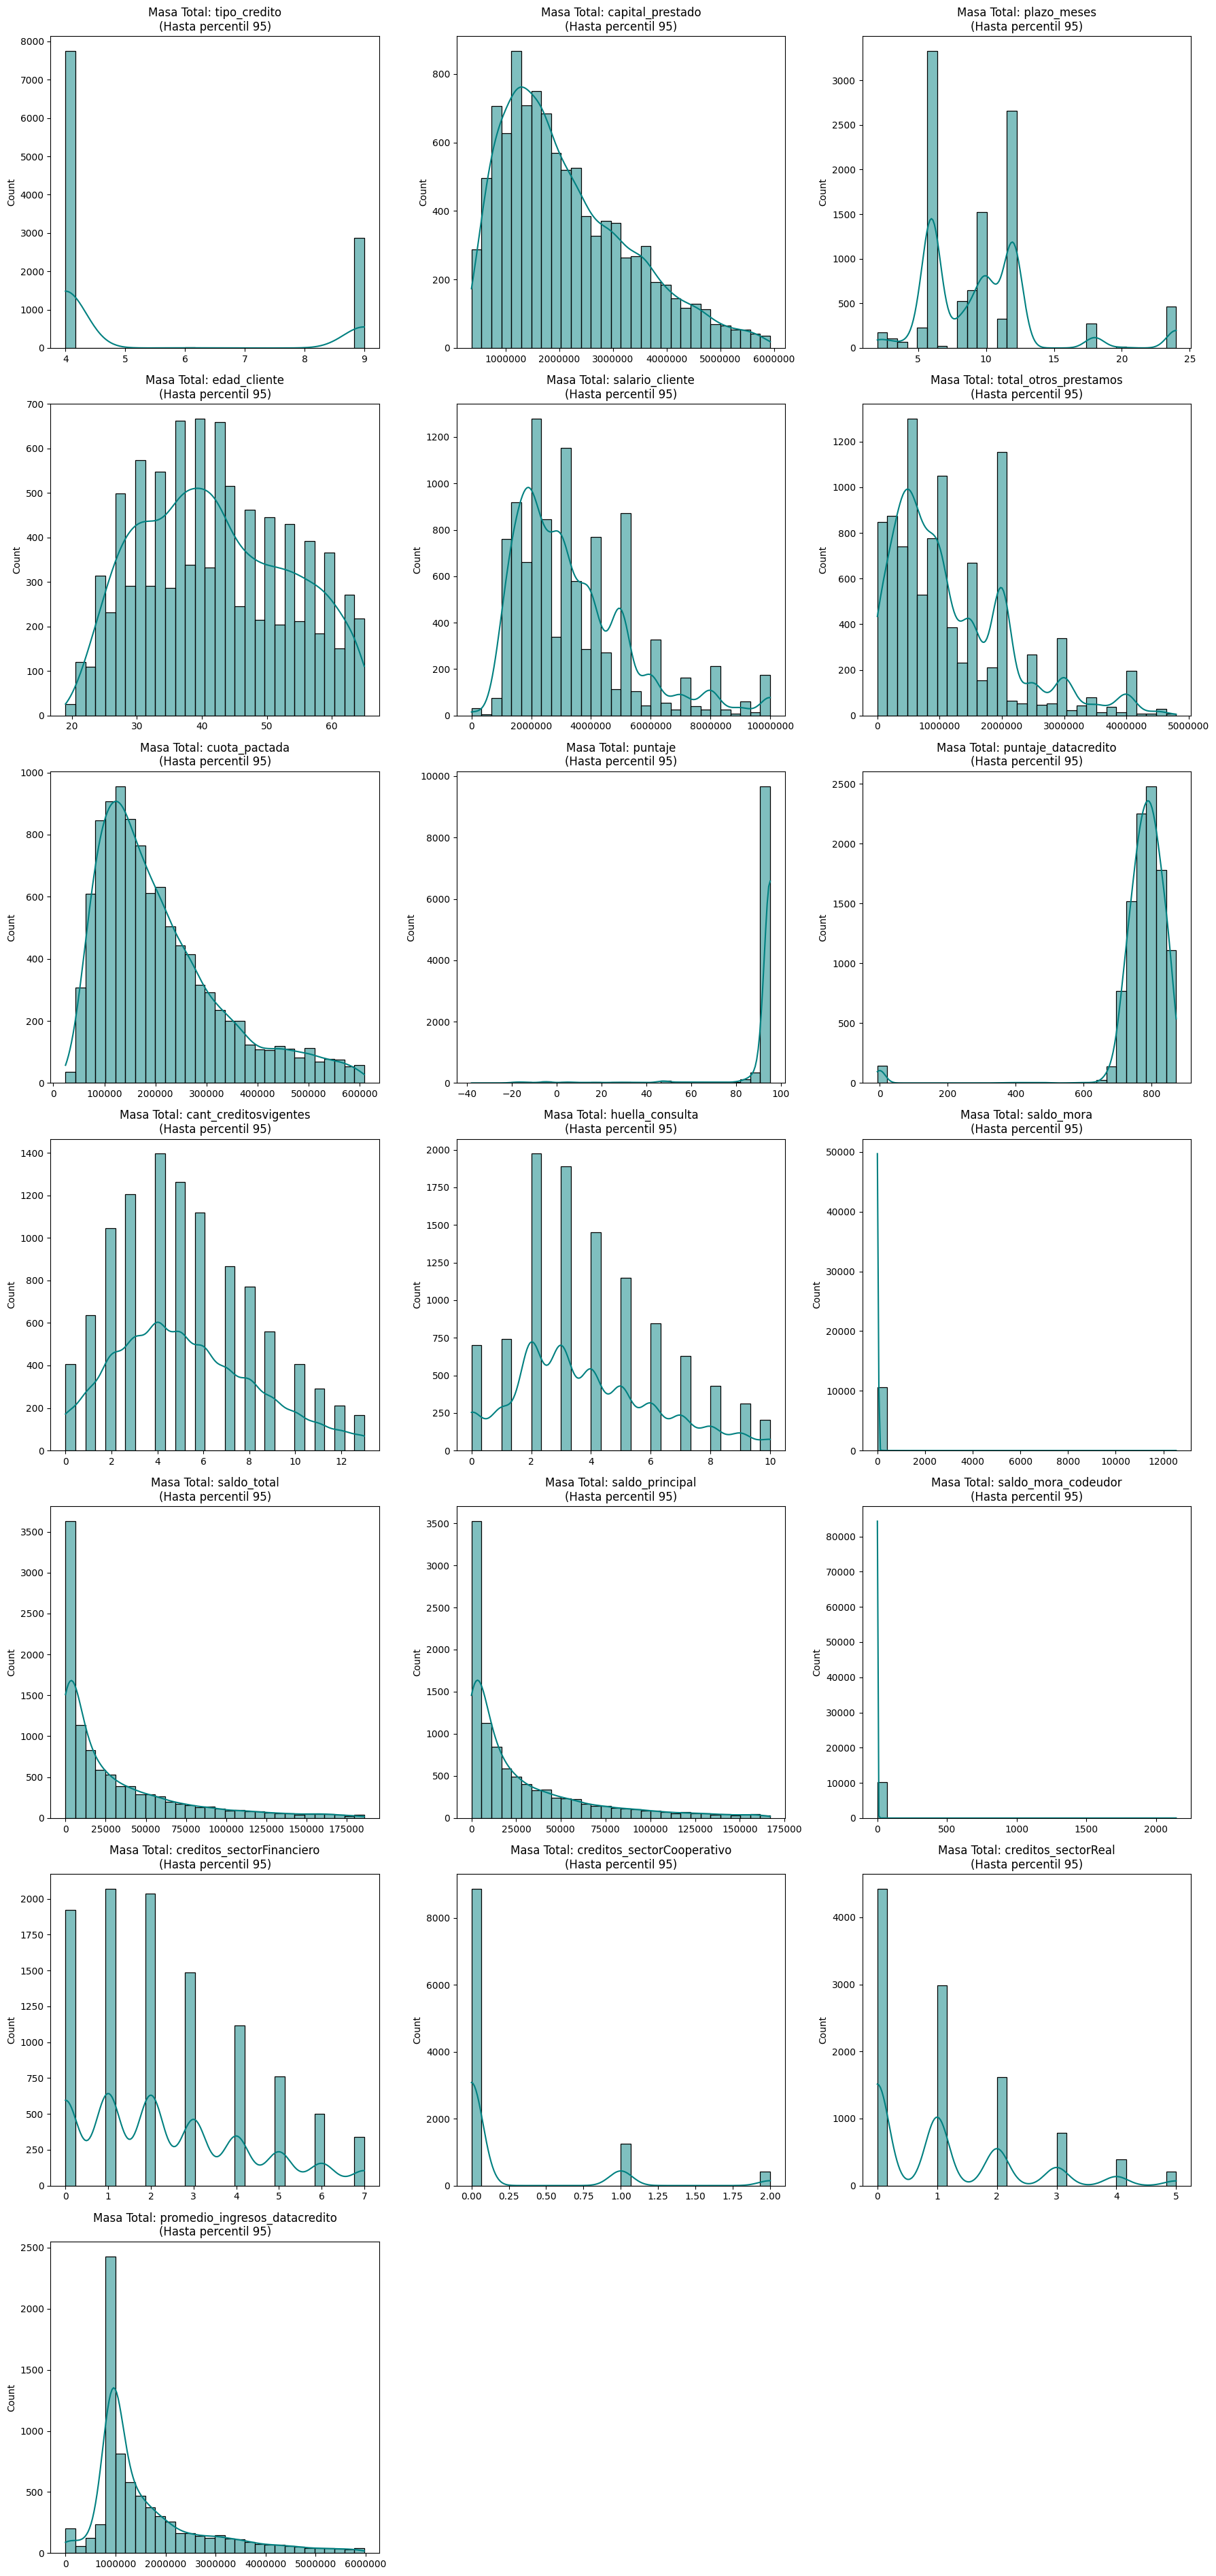

In [42]:
# 1. Identificación de columnas numéricas a graficar
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Pago_atiempo' in num_cols: num_cols.remove('Pago_atiempo')

# 2. Configuración de la matriz de subplots
n_num = len(num_cols)
fig, axes = plt.subplots(nrows=(n_num + 2) // 3, ncols=3, figsize=(18, n_num * 2))
axes = axes.flatten()

# 3. Iteración con filtrado dinámico para ver la "masa total"
for i, col in enumerate(num_cols):
    # Calculamos el percentil 95 para ignorar el 5% de datos más extremos y ver la masa central [1]
    # Si la variable tiene muchos ceros o es muy pequeña, usamos el percentil 99
    limite_superior = df[col].quantile(0.95)
    
    # En caso de que el percentil 95 sea 0 (columnas con muchos nulos/ceros), graficamos todo
    if limite_superior == 0: limite_superior = df[col].max()
    
    data_filtrada = df[df[col] <= limite_superior][col]
    
    # Gráfico de distribución
    sns.histplot(data_filtrada, kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Masa Total: {col}\n(Hasta percentil 95)', fontsize=12)
    axes[i].set_xlabel('')
    
    # Formatear el eje X para evitar notación científica y ver los millones claramente
    axes[i].ticklabel_format(style='plain', axis='x')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)): fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Outliers

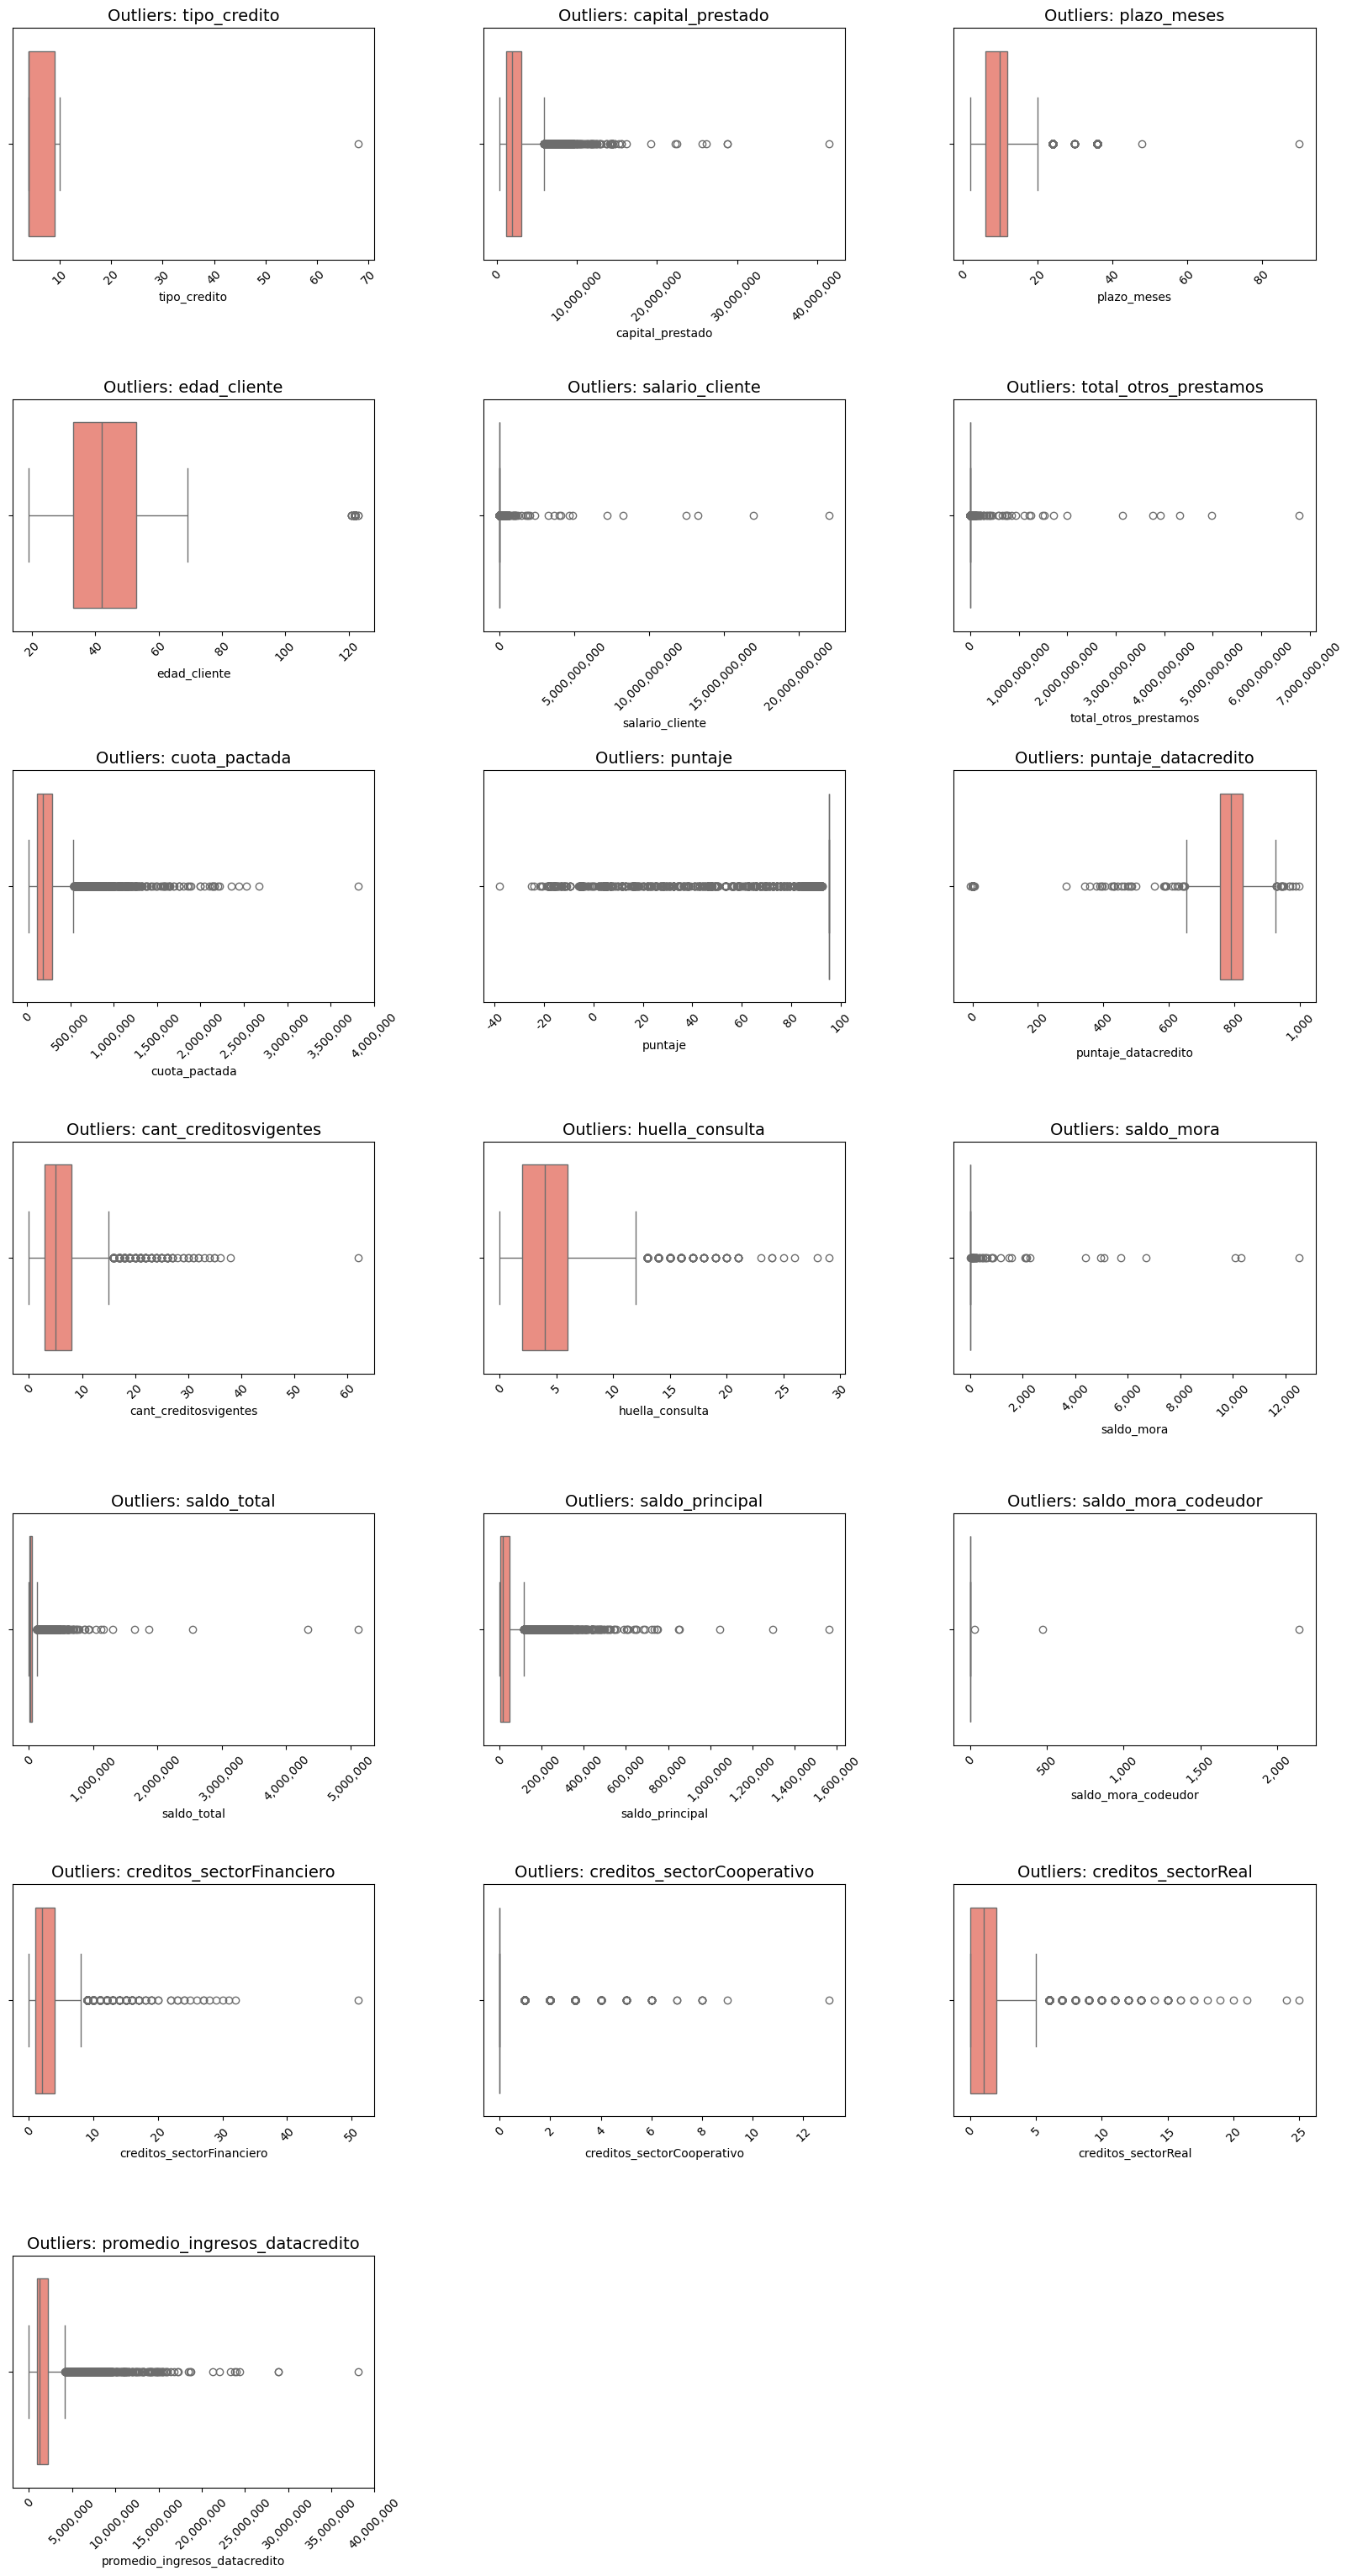

In [43]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(nrows=(n_num + 2) // 3, ncols=3, figsize=(20, n_num * 2)) 
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Outliers: {col}', fontsize=14)
    
    # Formateador de miles/millones
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # CLAVE: Rotamos las etiquetas para que no se superpongan horizontalmente
    axes[i].tick_params(axis='x', rotation=45) 

for j in range(i + 1, len(axes)): fig.delaxes(axes[j])

# Ajuste manual del espacio si tight_layout no es suficiente
plt.subplots_adjust(hspace=0.6, wspace=0.3) # hspace controla el espacio vertical
plt.show()

## 4. Analisis Bivariado

### Variables categoricas


--- Frecuencias para: tipo_laboral ---


,Conteo,Porcentaje (%)
tipo_laboral,,
Empleado,6754,62.75
Independiente,4009,37.25



--- Frecuencias para: tendencia_ingresos ---


,Conteo,Porcentaje (%)
tendencia_ingresos,,
Creciente,5294,49.19
NaN,2990,27.78
Decreciente,1291,11.99
Estable,1188,11.04



--- Frecuencias para: Pago_atiempo ---


,Conteo,Porcentaje (%)
Pago_atiempo,,
1,10252,95.25
0,511,4.75


C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\534464096.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=orden)
C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\534464096.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=orden)
C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\534464096.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=orden)


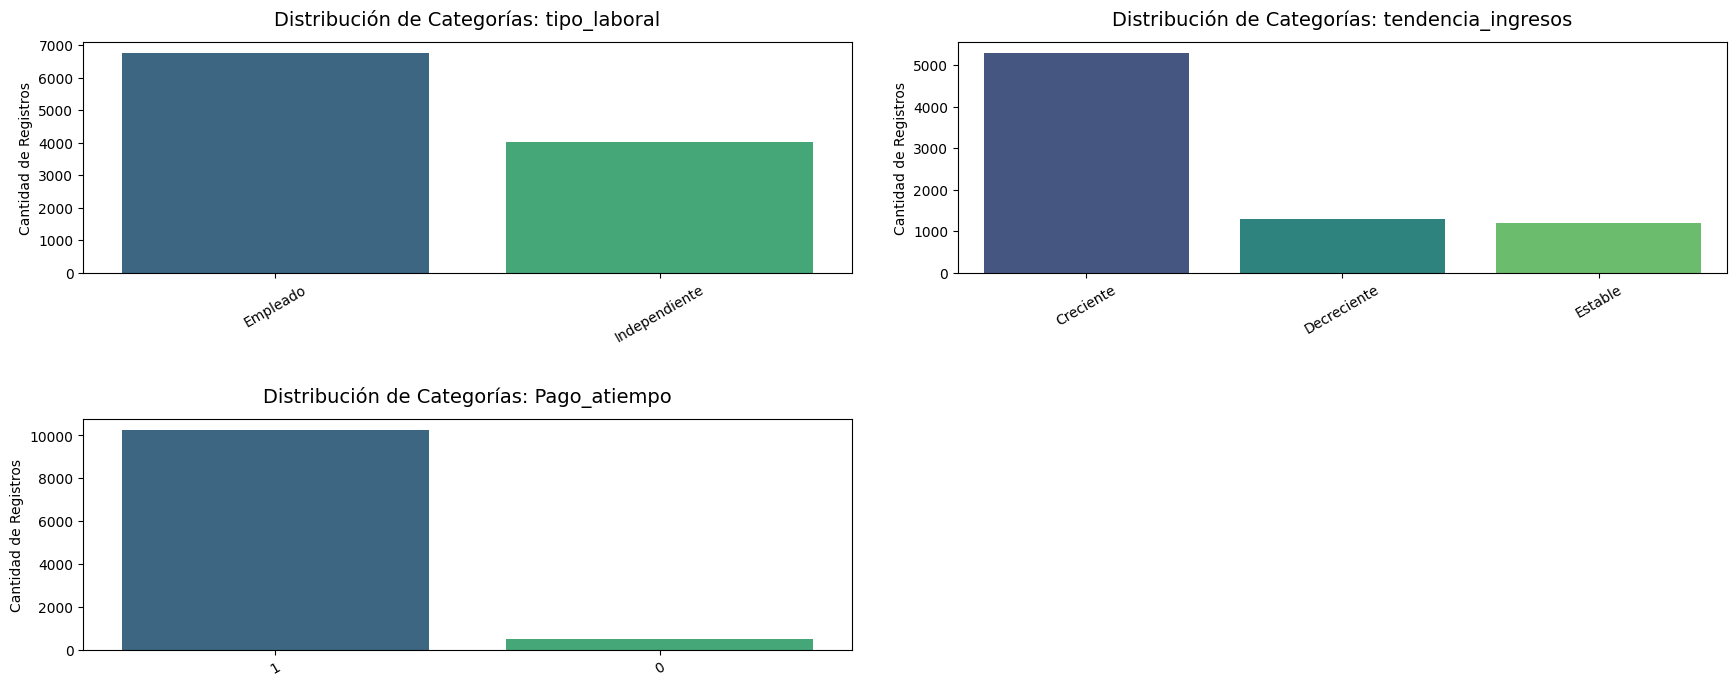

In [44]:
# Incluimos 'Pago_atiempo' (target) y las columnas de texto (object)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Aseguramos que la variable objetivo esté en la lista para su análisis
if 'Pago_atiempo' not in cat_cols and 'Pago_atiempo' in df.columns:
    cat_cols.append('Pago_atiempo')

# 2. Resumen estadístico de frecuencias (Tablas)
for col in cat_cols:
    print(f"\n--- Frecuencias para: {col} ---")
    conteo = df[col].value_counts(dropna=False)
    porcentaje = (df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
    df_resumen = pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': porcentaje})
    display(df_resumen)

# 3. Visualización en Subplots
n_cat = len(cat_cols)
fig, axes = plt.subplots(nrows=(n_cat + 1) // 2, ncols=2, figsize=(18, n_cat * 2.5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Ordenar por frecuencia para mejor lectura visual
    orden = df[col].value_counts().index
    
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=orden)
    axes[i].set_title(f'Distribución de Categorías: {col}', fontsize=14, pad=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Registros')
    
    # Rotación para evitar superposición de nombres largos (como en tipo_laboral)
    axes[i].tick_params(axis='x', rotation=30)

# Ocultar ejes que sobren
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

### 5.1. Variables Numéricas vs. Pago a Tiempo
Utilizamos diagramas de caja (Boxplots) para comparar la distribución de las variables clave entre quienes pagan a tiempo y quienes entran en mora.

C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\25005946.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='Pago_atiempo', y=col, ax=axes[i], palette='Set2')
C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\25005946.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='Pago_atiempo', y=col, ax=axes[i], palette='Set2')
C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\25005946.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='Pago_atiempo', y=col, ax=axes[i], palette='Set2'

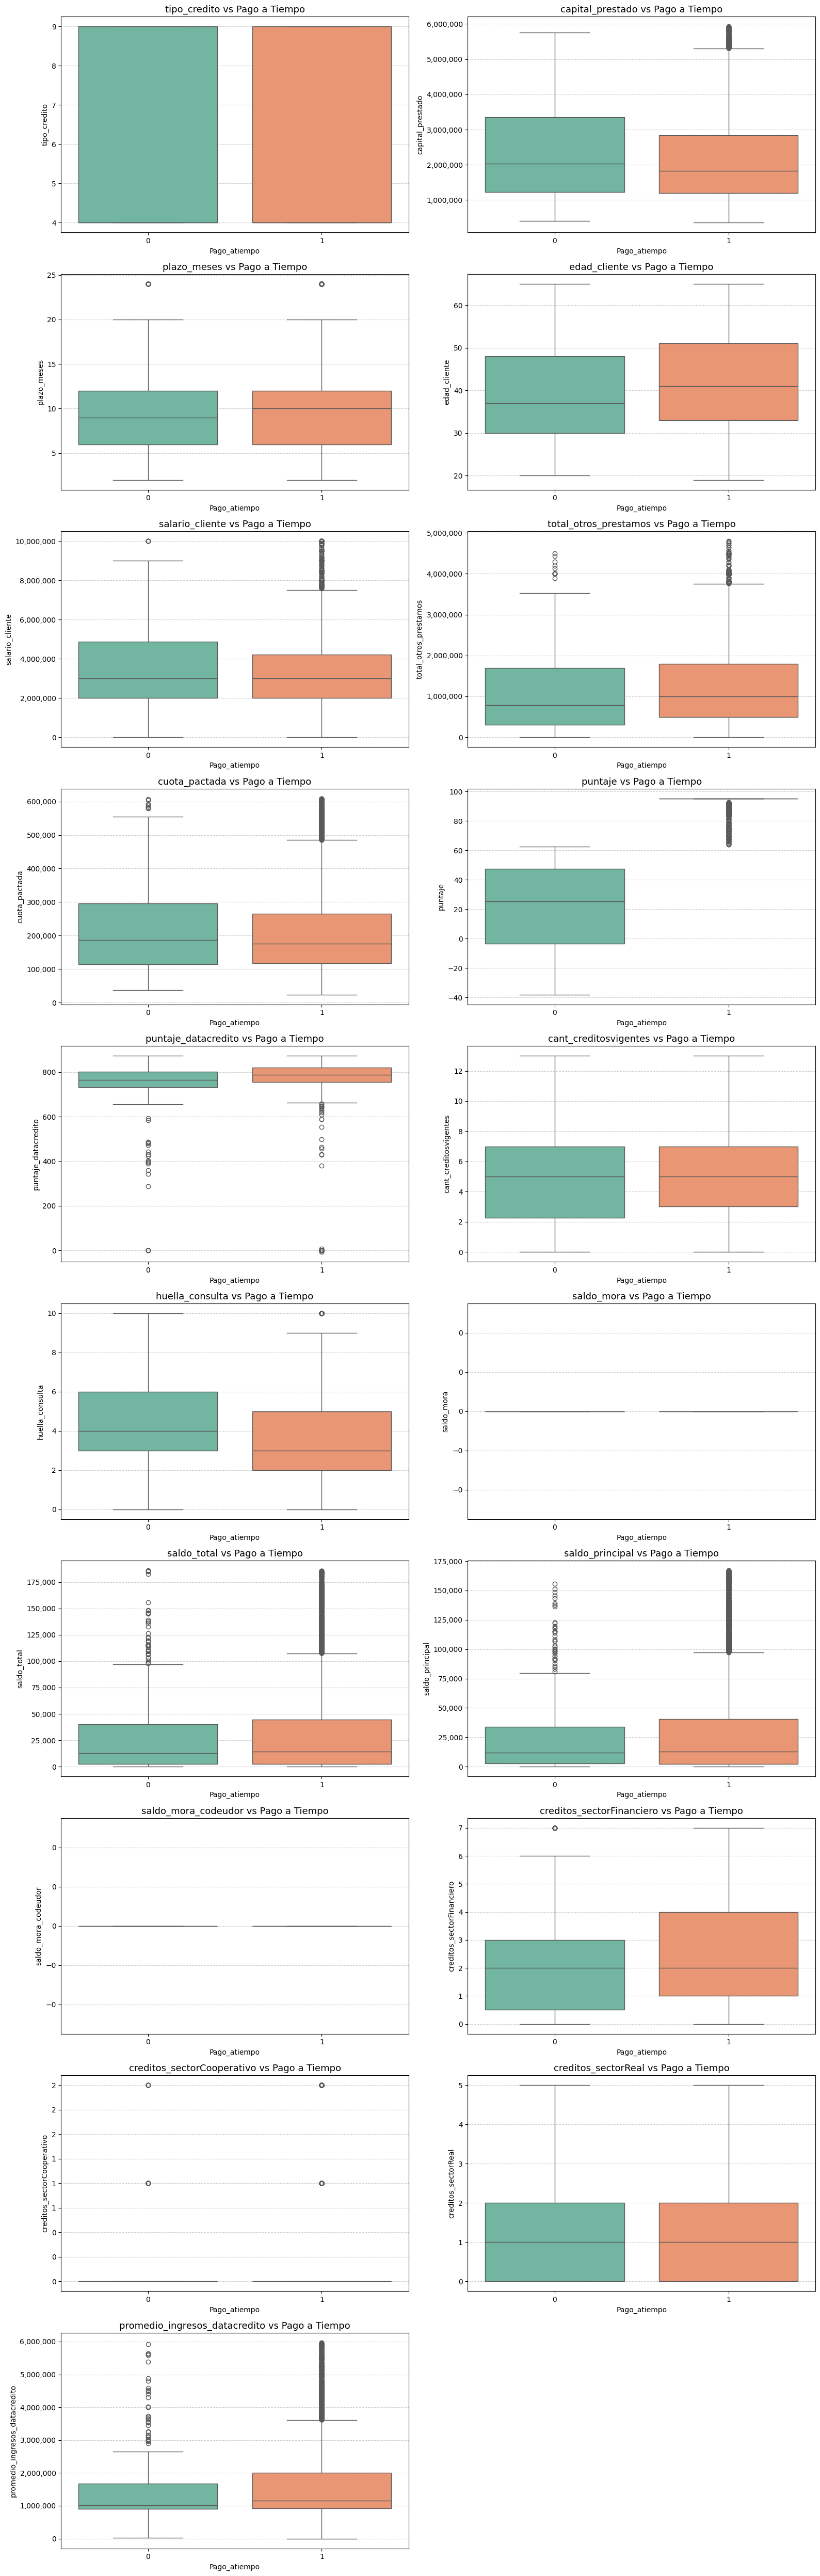

### RESUMEN ESTADÍSTICO POR GRUPO DE PAGO


tipo_credito             capital_prestado               \
                     mean median  std             mean       median   
Pago_atiempo                                                          
0                    5.40   4.00 2.23     2,781,774.11 2,268,000.00   
1                    5.41   4.00 2.34     2,416,996.27 1,908,446.40   

                          plazo_meses             edad_cliente  ...  \
                      std        mean median  std         mean  ...   
Pago_atiempo                                                    ...   
0            1,942,337.70       12.45  10.00 9.27        41.77  ...   
1            1,906,438.41       10.48  10.00 6.46        44.06  ...   

             creditos_sectorFinanciero creditos_sectorCooperativo              \
                                   std                       mean median  std   
Pago_atiempo                                                                    
0                                 2.64                       0.20   0.00 0.62   
1                                 2.75                       0.27   0.00 0.72   

             creditos_sectorReal             promedio_ingresos_datacredito  \
                            mean median  std                          mean   
Pago_atiempo                                                                 
0                           1.49   1.00 2.05                  1,605,742.05   
1                           1.29   1.00 1.81                  2,023,447.77   

                                        
                   median          std  
Pago_atiempo                            
0            1,052,529.00 1,668,892.06  
1            1,211,296.00 2,161,702.28  

[2 rows x 57 columns]

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Configuración de escala y formato
pd.options.display.float_format = '{:,.2f}'.format
num_cols = [c for c in df.select_dtypes(include=['number']).columns if c != 'Pago_atiempo']

# 1. Crear la cuadrícula de subplots
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Filtrado de outliers para visualización (P95) como en tus fuentes [3]
    limite = df[col].quantile(0.95)
    df_temp = df[df[col] <= limite]
    
    sns.boxplot(data=df_temp, x='Pago_atiempo', y=col, ax=axes[i], palette='Set2')
    
    # FORMATO: Quitar 1e7 y poner separadores de miles
    axes[i].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[i].set_title(f'{col} vs Pago a Tiempo', fontsize=13)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Ocultar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 2. Mostrar Tabla Resumen de Numéricas
print("### RESUMEN ESTADÍSTICO POR GRUPO DE PAGO")
resumen_num = df.groupby('Pago_atiempo')[num_cols].agg(['mean', 'median', 'std'])
display(resumen_num)


## 5. Analisis Multivariable 

In [46]:
# A. Atributo Calculado (Derivado) [4]
# El ratio de endeudamiento es clave para el riesgo crediticio
df['ratio_endeudamiento'] = df['saldo_total'] / df['salario_cliente']



In [47]:
# 3. Tabla de Resultados del Atributo Calculado
print("### Resumen Estadístico: Ratio de Endeudamiento (Deuda / Salario)")
# Agrupamos por la variable objetivo para comparar comportamientos [4]
resumen = df.groupby('Pago_atiempo')['ratio_endeudamiento'].agg(['mean', 'median', 'max'])
resumen.columns = ['Ratio Medio', 'Mediana', 'Máximo']
resumen.index = ['No Pago (0)', 'Pago a Tiempo (1)']

display(resumen.round(2))

### Resumen Estadístico: Ratio de Endeudamiento (Deuda / Salario)


,Ratio Medio,Mediana,Máximo
No Pago (0),inf,0.00,inf
Pago a Tiempo (1),inf,0.01,inf


inf en el Máximo y la Media: Esto confirma que hay clientes en tu base de datos con salario = 0. Al haber al menos un valor "infinito", el promedio (mean) de todo el grupo también se vuelve infinito

Hallazgo: Se detectaron registros con salario igual a cero, lo que genera valores inconsistentes (inf) en el ratio de endeudamiento.


In [48]:
# 1. Creamos el ratio evitando los ceros o reemplazando inf por NaN
df['ratio_endeudamiento'] = df['saldo_total'] / df['salario_cliente']
df['ratio_endeudamiento'] = df['ratio_endeudamiento'].replace([np.inf, -np.inf], np.nan)

# 2. Ahora la tabla mostrará números reales (ignorando los errores)
print("### Resumen Estadístico Limpio (sin salarios cero)")
resumen = df.groupby('Pago_atiempo')['ratio_endeudamiento'].agg(['mean', 'median', 'max'])
display(resumen.round(2))

### Resumen Estadístico Limpio (sin salarios cero)


,mean,median,max
Pago_atiempo,,,
0,0.01,0.00,0.09
1,0.02,0.01,59.58


#### Interpretación del Atributo Calculado: Ratio de Endeudamiento
Tras limpiar los valores infinitos (causados por salarios en cero), el análisis del ratio (Saldo Total / Salario) revela lo siguiente:

1. **Detección de Valores Atípicos (Outliers):** Se identifica un valor máximo de **59.58** en el grupo de 'Pago a Tiempo'. Este registro indica una deuda que supera casi 60 veces el ingreso mensual, lo cual es financieramente atípico y debe ser revisado en la etapa de ingeniería de características.
2. **Relación con el Impago:** Contrario a la intuición financiera inicial, el grupo de 'No Pago' presenta un ratio máximo de apenas **0.09**, significativamente menor al del grupo cumplido. Esto sugiere que el sobreendeudamiento no es el factor principal de mora en este dataset específico.
3. **Regla de Validación Propuesta:** 
   - Es necesario investigar otras variables para explicar la mora, dado que el saldo total no parece ser el disparador del incumplimiento.

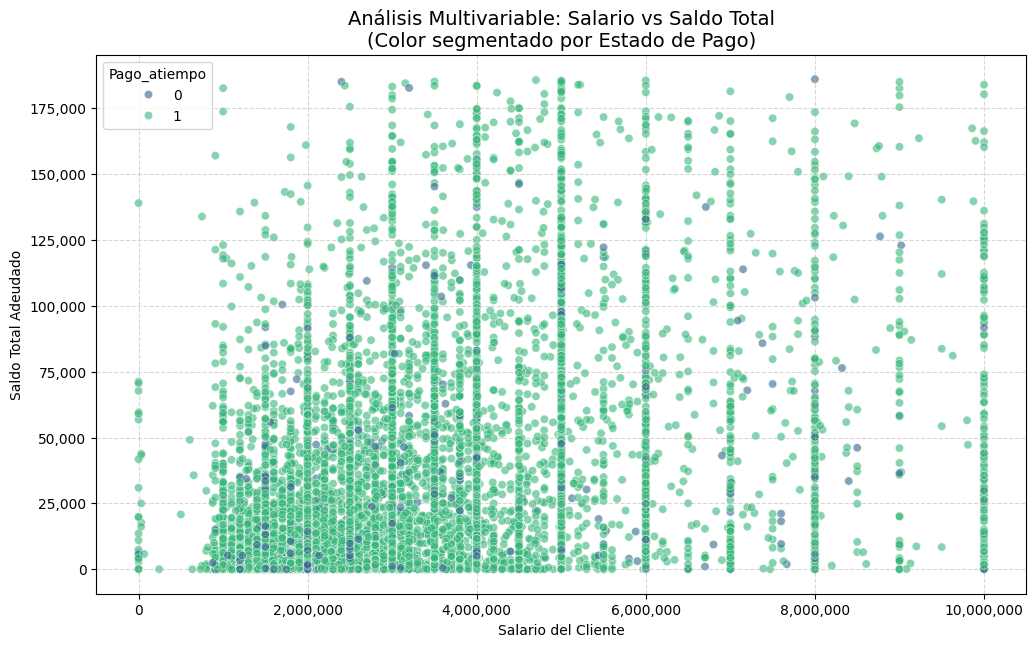

In [49]:
# 2. Gráfico de Dispersión (Scatterplot) con Parámetro HUE
plt.figure(figsize=(12, 7))

# Filtramos el percentil 95 para que los outliers no "aplasten" el gráfico y sea legible [2]
lim_salario = df['salario_cliente'].quantile(0.95)
lim_saldo = df['saldo_total'].quantile(0.95)
df_plot = df[(df['salario_cliente'] <= lim_salario) & (df['saldo_total'] <= lim_saldo)].copy()

ax = sns.scatterplot(data=df_plot, x='salario_cliente', y='saldo_total', 
                     hue='Pago_atiempo', alpha=0.6, palette='viridis')

# FORMATEO DE NÚMEROS: Quitar el 1e6/1e7 y poner separadores de miles [3]
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Análisis Multivariable: Salario vs Saldo Total\n(Color segmentado por Estado de Pago)', fontsize=14)
plt.xlabel('Salario del Cliente')
plt.ylabel('Saldo Total Adeudado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [50]:
# Revisar columnas numéricas con ceros
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    cant_ceros = (df[col] == 0).sum()
    if cant_ceros > 0:
        print(f"{col}: {cant_ceros} registros con valor 0")

salario_cliente: 24 registros con valor 0
total_otros_prestamos: 445 registros con valor 0
puntaje_datacredito: 145 registros con valor 0
cant_creditosvigentes: 405 registros con valor 0
huella_consulta: 700 registros con valor 0
saldo_mora: 10552 registros con valor 0
saldo_total: 789 registros con valor 0
saldo_principal: 633 registros con valor 0
saldo_mora_codeudor: 10170 registros con valor 0
creditos_sectorFinanciero: 1924 registros con valor 0
creditos_sectorCooperativo: 8868 registros con valor 0
creditos_sectorReal: 4426 registros con valor 0
promedio_ingresos_datacredito: 7 registros con valor 0
Pago_atiempo: 511 registros con valor 0
ratio_endeudamiento: 788 registros con valor 0


 Salario vs Saldo Total
Este gráfico de dispersión permite identificar patrones de comportamiento cruzando la capacidad económica con el nivel de endeudamiento:

1. **Relación de Capacidad vs. Deuda:** Se observa que la mayoría de los clientes se concentran en salarios de entre 2,000,000 y 6,000,000 con deudas menores a 100,000. Aquellos puntos ubicados en la parte superior izquierda (bajo salario y alta deuda) representan el segmento de mayor riesgo potencial.
2. **Visualización del Desbalance:** La predominancia de puntos verdes (Clase 1) confirma el desbalance de clases detectado anteriormente (~95% de cumplimiento), lo que sugiere que el modelo necesitará técnicas de balanceo en etapas posteriores.
3. **Identificación de Reglas de Validación:** 
   - Se observa que los casos de impago (puntos azules) aparecen en diversos niveles salariales, lo que justifica la creación del atributo calculado **'ratio_endeudamiento'** para capturar mejor el riesgo.
   - **Regla propuesta:** Clientes con saldos totales cercanos al límite superior de su rango salarial deben ser monitoreados con mayor rigurosidad.

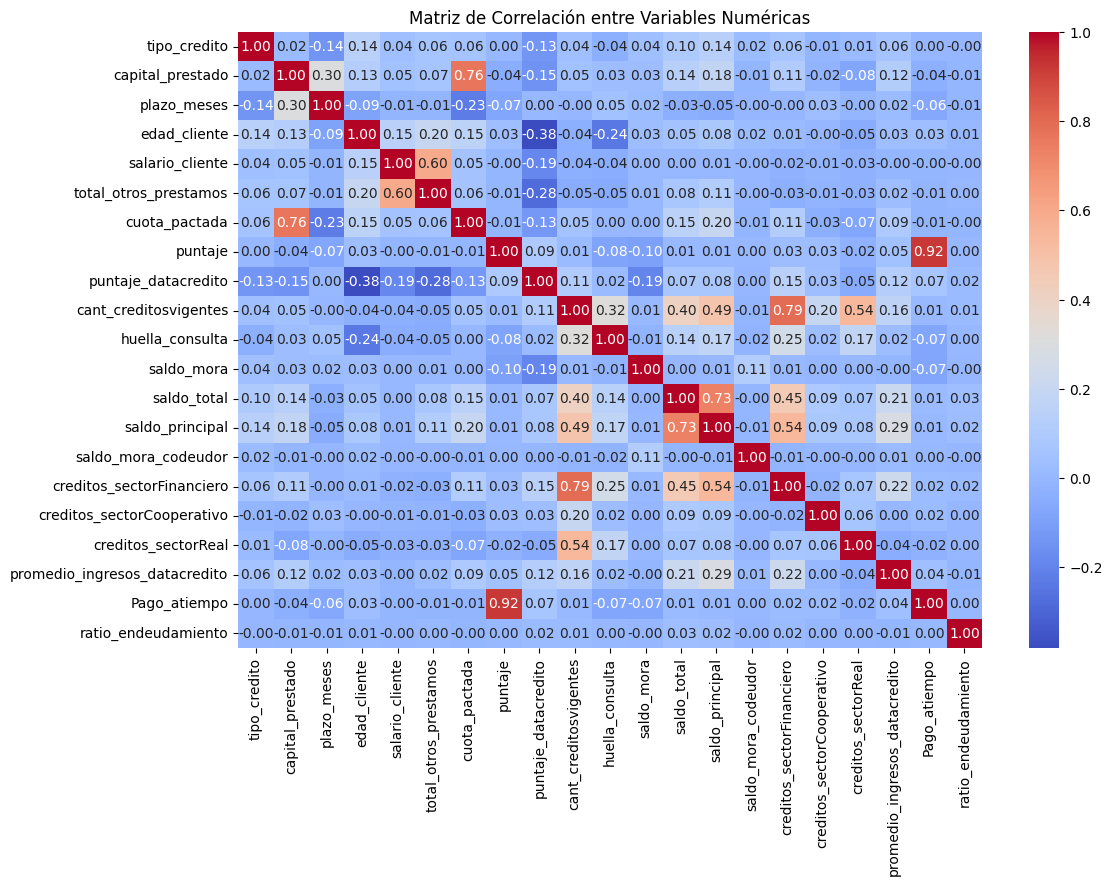

In [51]:

# =========================
# 1. Matriz de correlación
# =========================
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()



### Interpretación de la Matriz de Correlación

#### Hallazgos principales:

- Se observan correlaciones elevadas entre variables de saldo:
  - `capital_prestado` y `cuota_pactada`
  - `saldo_total` y `saldo_principal`

Estas relaciones son coherentes desde el punto de vista financiero, ya que representan componentes relacionados del endeudamiento del cliente.

---

- La variable `ratio_endeudamiento` no presenta una correlación significativa con la variable objetivo `Pago_atiempo`, lo que sugiere que el nivel de endeudamiento relativo no es un predictor directo del comportamiento de pago en este conjunto de datos.

---

#### Hallazgo crítico: posible Data Leakage

Se detecta una correlación extremadamente alta (~0.92) entre la variable `puntaje` y la variable objetivo `Pago_atiempo`.

Este comportamiento sugiere que `puntaje` podría estar incorporando información derivada del historial de pagos del cliente, lo que implicaría un posible caso de data leakage.

Por este motivo, esta variable será excluida de la etapa de modelado para asegurar la capacidad de generalización del modelo en nuevos usuarios.

C:\Users\Agus y Ro\AppData\Local\Temp\ipykernel_10592\1380870349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="Set2")


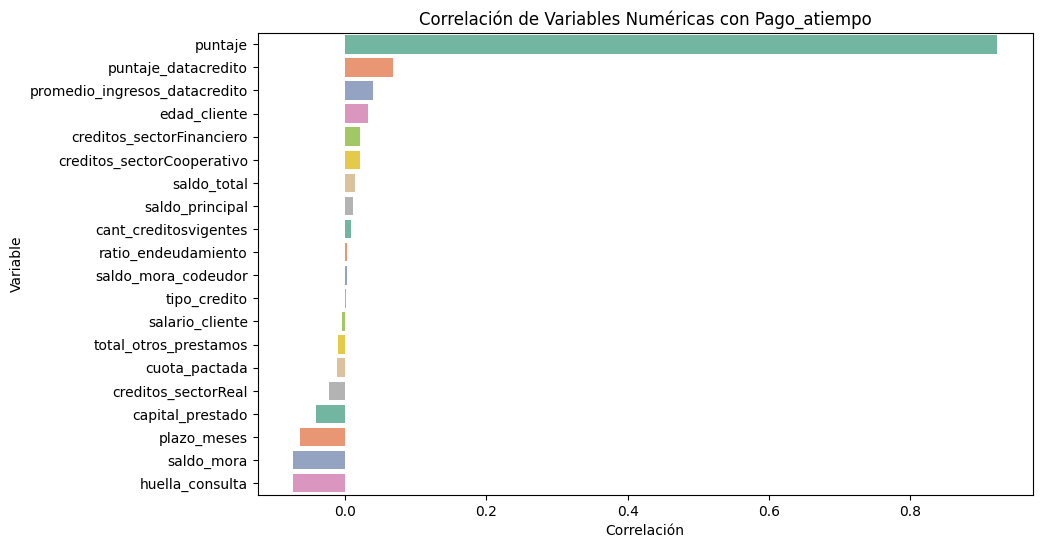

In [52]:
corr_target = df[num_cols].corr()["Pago_atiempo"].drop("Pago_atiempo").sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette="Set2")
plt.title("Correlación de Variables Numéricas con Pago_atiempo")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()


## 6. Reglas de Validación Propuestas para Ingeniería de Características

Basado en el análisis exploratorio, se identifican las siguientes observaciones relevantes para la etapa de feature engineering:

---

### 1. Tratamiento de valores nulos
La variable `tendencia_ingresos` presenta aproximadamente un 27% de valores faltantes.

Se propone evaluar en la etapa de ingeniería de características:

- imputación por moda, dependiendo del comportamiento en producción

---

### 2. Validación de ingresos
Se identificaron registros con `salario_cliente = 0`.

Estos casos podrían representar ausencia de ingresos reportados o desempleo.

Se propone evaluar en feature engineering:
- creación de variable indicadora (`salario_cero`)
- imputación del valor como nulo (`NaN`) para tratamiento estadístico

---

### 3. Manejo de outliers
Se observan distribuciones altamente sesgadas en variables financieras como:

- `capital_prestado`
- `saldo_total`
- `saldo_principal`
- `total_otros_prestamos`

Dado el comportamiento típico de variables financieras (colas largas), se recomienda **evaluar distintas estrategias de tratamiento en la fase de modelado**, como:
- transformación logarítmica
- o métodos robustos de escalamiento

No se define una eliminación directa de valores extremos en esta etapa.

---

### 4. Correlaciones entre variables
Se identifican correlaciones elevadas entre variables relacionadas con saldos (ej. `saldo_total` y `saldo_principal`).

Sin embargo, la decisión de eliminar variables redundantes será evaluada en la etapa de modelado, considerando el impacto en el desempeño del modelo.

---

### 5. Riesgo de Data Leakage
La variable `puntaje` presenta una correlación elevada con la variable objetivo (`0.92`) y un comportamiento anómalo en su distribución.

Se considera una variable de alto riesgo de fuga de información (data leakage), ya que podría no estar disponible al momento de predecir nuevos usuarios.

Por lo tanto, será evaluada para su exclusión en la etapa de ingeniería de características.

---

### 6. Validación experimental
Se propone realizar pruebas comparativas en la etapa de modelado para evaluar el impacto de variables críticas en el desempeño del modelo, garantizando robustez y generalización.

In [54]:
df["puntaje"].value_counts().head(20)

puntaje
95.23     9407
89.98       99
89.23       82
92.00       73
47.61       59
84.73       59
91.73       56
92.23       51
90.56       46
91.41       45
88.23       44
86.83       34
81.23       29
91.03       25
85.90       21
58.60       17
-5.10       16
-18.47      16
92.43       14
88.77       13
Name: count, dtype: int64